# Linear Regression
## Car Fuel Efficiency

In [1]:
#importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge, Lasso


%matplotlib inline

In [2]:
pd.__version__

'2.3.1'

### Load the Data set

In [3]:
# Loading the Data set
df = pd.read_csv("D:/Git REPO/ML-ML Zoomcamp-September/Chapter-1-Linear-Regression/car_fuel_efficiency.csv")
df.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


In [4]:
# Understanding the data
df.info()
df.describe()
print()
print(len(df))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9704 entries, 0 to 9703
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   engine_displacement  9704 non-null   int64  
 1   num_cylinders        9222 non-null   float64
 2   horsepower           8996 non-null   float64
 3   vehicle_weight       9704 non-null   float64
 4   acceleration         8774 non-null   float64
 5   model_year           9704 non-null   int64  
 6   origin               9704 non-null   object 
 7   fuel_type            9704 non-null   object 
 8   drivetrain           9704 non-null   object 
 9   num_doors            9202 non-null   float64
 10  fuel_efficiency_mpg  9704 non-null   float64
dtypes: float64(6), int64(2), object(3)
memory usage: 834.1+ KB

9704


### Data Cleaning

In [5]:
# Checking missing values
num_cols_with_missing = df.isnull().any().sum()
print(num_cols_with_missing)

4


In [6]:
# original median and missing count
hp = df['horsepower']
nan_before = hp.isna().sum()
median_before = hp.median()
print(f"Missing horsepower values before filling: {nan_before}")
print(f"Median horsepower before filling: {median_before}")

# most frequent value (mode)
mode_series = hp.mode(dropna=True)
mode_value = mode_series.iloc[0] if len(mode_series) > 0 else None
print(f"Most frequent horsepower (mode): {mode_value}")

# fill missing with mode and recompute median
df_filled = df.copy()
if mode_value is not None:
    df_filled['horsepower'] = df_filled['horsepower'].fillna(mode_value)

nan_after = df_filled['horsepower'].isna().sum()
median_after = df_filled['horsepower'].median()
print(f"Missing horsepower values after filling: {nan_after}")
print(f"Median horsepower after filling with mode: {median_after}")

# Did the median change?
if median_after > median_before:
    result = 'Yes, it increased'
elif median_after < median_before:
    result = 'Yes, it decreased'
else:
    result = 'No'

print('Final answer: ', result)

Missing horsepower values before filling: 708
Median horsepower before filling: 149.0
Most frequent horsepower (mode): 152.0
Missing horsepower values after filling: 0
Median horsepower after filling with mode: 152.0
Final answer:  Yes, it increased


In [7]:
# Filling the missing values 
df['num_cylinders'] = df['num_cylinders'].fillna(df['num_cylinders'].mode()[0]) # Categorical column, using mode
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].median()) # Continous Numerical column, using median
df['acceleration'] = df['acceleration'].fillna(df['acceleration'].median()) # Continous Numerical column, using median
df['num_doors'] = df['num_doors'].fillna(df['num_doors'].mode()[0]) # Categorical column, using mode

# Verifying if there are any missing values
df.isnull().sum()

engine_displacement    0
num_cylinders          0
horsepower             0
vehicle_weight         0
acceleration           0
model_year             0
origin                 0
fuel_type              0
drivetrain             0
num_doors              0
fuel_efficiency_mpg    0
dtype: int64

In [8]:
max_asia = df.loc[df['origin'] == 'Asia', 'fuel_efficiency_mpg'].max()
print("Max MPG for Asia:", max_asia)


Max MPG for Asia: 23.759122836520497


In [9]:
# Sum of weights
asia_cars = df[df['origin'].astype(str).str.lower() == 'asia'][['vehicle_weight', 'model_year']].head(7)

if len(asia_cars) < 7:
    raise ValueError(f"Expected 7 Asia cars but found {len(asia_cars)}. Check the 'origin' values and casing.")

# ensure numeric and shape (7,2)
X = asia_cars[['vehicle_weight', 'model_year']].to_numpy(dtype=float)

# target vector (must match number of rows)
y = np.array([1100, 1300, 800, 900, 1000, 1100, 1200], dtype=float)
if X.shape[0] != y.shape[0]:
    raise ValueError(f"X rows ({X.shape[0]}) and y length ({y.shape[0]}) must match.")

# compute weights robustly using pseudoinverse to avoid singular matrix inversion errors
w = np.linalg.pinv(X) @ y

print("w:", w)
print("Sum of w elements:", np.sum(w))


w: [0.01386421 0.5049067 ]
Sum of w elements: 0.5187709081074021


### Exploratory Data Analysis and Preprocessing

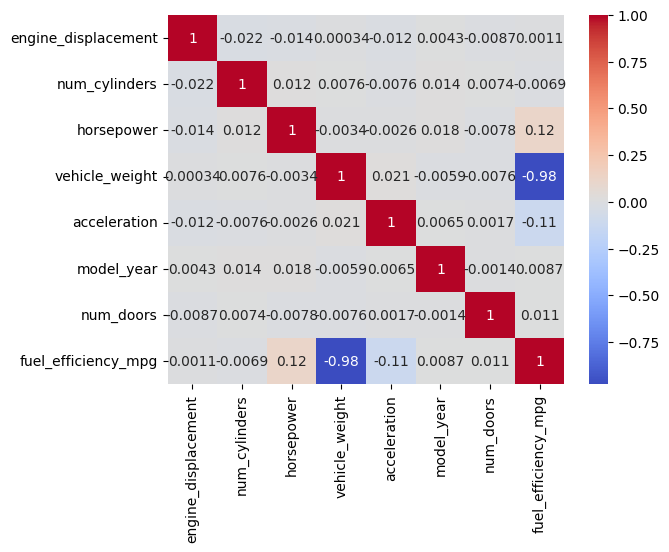

In [10]:
# Correlation (numerical features only)
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

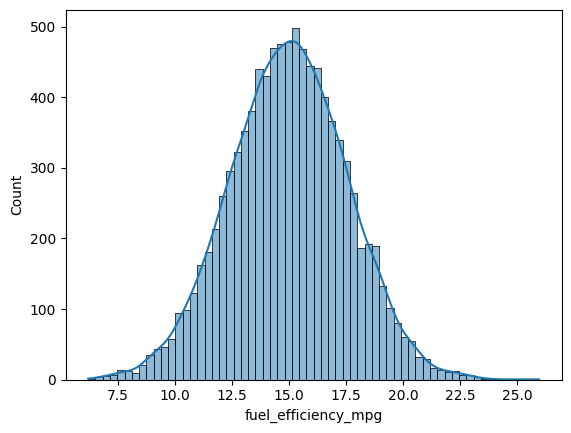

In [11]:
# Distribution of target
sns.histplot(df['fuel_efficiency_mpg'], kde=True)
plt.show()

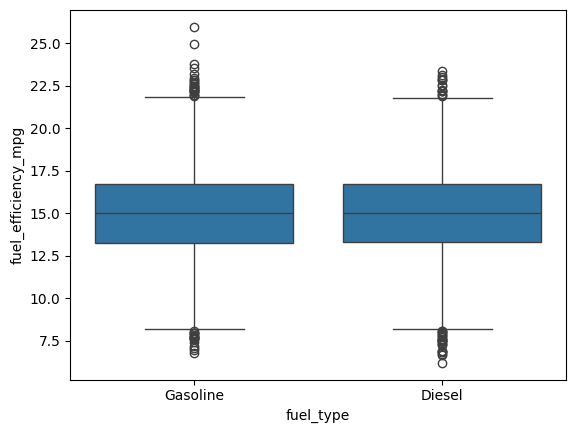

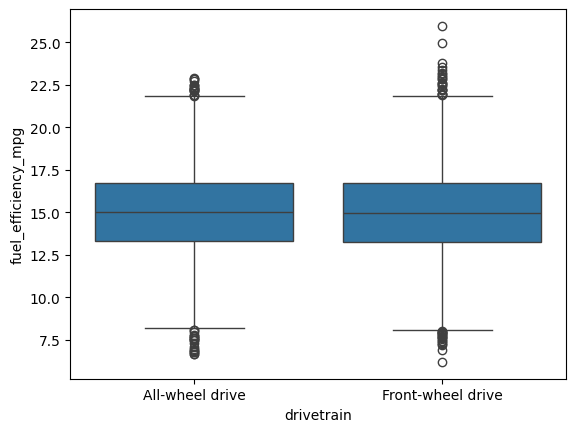

In [12]:
# Compare categorical features
sns.boxplot(x='fuel_type', y='fuel_efficiency_mpg', data=df)
plt.show()

sns.boxplot(x='drivetrain', y='fuel_efficiency_mpg', data=df)
plt.show()

In [13]:
# Checking fuels type in the dataset
fuel_types = df['fuel_type'].nunique()
print(fuel_types)

2


In [14]:
# Identify numerical and categorical columns
num_cols = df.select_dtypes(include=['int64','float64']).columns
# String columns
cat_cols = df.select_dtypes(include=['object']).columns
print("Numerical Columns: ", num_cols)
print("Categorical Columns: ", cat_cols)

Numerical Columns:  Index(['engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight',
       'acceleration', 'model_year', 'num_doors', 'fuel_efficiency_mpg'],
      dtype='object')
Categorical Columns:  Index(['origin', 'fuel_type', 'drivetrain'], dtype='object')


### Feature Engineering

In [15]:
# Encode categorical variables
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [16]:
# Splitting the data into features and target
X = df.drop('fuel_efficiency_mpg', axis=1)
y = df['fuel_efficiency_mpg']

# Standardizing the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Model Training

In [17]:
# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Training the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train) 

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Model Prediction

In [18]:
# Predictions
y_pred = model.predict(X_test)

### Model Evaluation

In [19]:
# Evaluating the model
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² Score:", r2_score(y_test, y_pred))

MAE: 0.31501809986139506
MSE: 0.15647033104627206
RMSE: 0.39556330851871496
R² Score: 0.975701630820773


### Model Optimization

In [20]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)   # fit on train
X_test_poly  = poly.transform(X_test)        # transform test

In [21]:
# Regularizing the model
rridge = Ridge(alpha=1.0).fit(X_train_poly, y_train)
lasso = Lasso(alpha=0.01).fit(X_train_poly, y_train)

In [22]:
y_pred_ridge = rridge.predict(X_test_poly)
y_pred_lasso = lasso.predict(X_test_poly)

In [23]:
# Evaluate model performance
print("Ridge Model Evaluation:")
print("MAE:", mean_absolute_error(y_test, y_pred_ridge))
print("MSE:", mean_squared_error(y_test, y_pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))
print("R² Score:", r2_score(y_test, y_pred_ridge))

print("\nLasso Model Evaluation:")
print("MAE:", mean_absolute_error(y_test, y_pred_lasso))
print("MSE:", mean_squared_error(y_test, y_pred_lasso))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))
print("R² Score:", r2_score(y_test, y_pred_lasso))

Ridge Model Evaluation:
MAE: 0.31712832434526567
MSE: 0.15912745602433426
RMSE: 0.39890782898350624
R² Score: 0.9752890043296

Lasso Model Evaluation:
MAE: 0.3158414999962274
MSE: 0.15766829042597572
RMSE: 0.3970746660591377
R² Score: 0.9755155990083832
